In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os

import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

from matplotlib import animation
import matplotlib
from ipywidgets import Video
from matplotlib.cm import prism

from ipywidgets import IntProgress
from IPython.display import display

repo_dir = str(Path(os.getcwd()).parents[1])

os.chdir(repo_dir + '/scripts/')
from utils import display_catalog
import utils

os.chdir(repo_dir + '/notebooks/misc/')

In [2]:
def average_angle(subdf):
    lats = np.radians(subdf.lat)
    lons = np.radians(subdf.lon)

    x = np.cos(lats)*np.cos(lons)
    y = np.cos(lats)*np.sin(lons)
    z = np.sin(lats)
    
    avg_x = np.mean(x)
    avg_y = np.mean(y)
    avg_z = np.mean(z)

    avg_lat = np.arcsin(avg_z)
    avg_lon = arctan(avg_x, avg_y)

    return pd.Series({'avg_lat':np.degrees(avg_lat), 'avg_lon':np.degrees(avg_lon)})
    
def arctan(x, y):
    if y/x > 0:
        if x > 0:
            return(np.arctan(y/x))
        else:
            return(np.arctan(y/x)-np.pi)
    else:
        if x > 0:
            return(np.arctan(y/x))
        else:
            return(np.pi+np.arctan(y/x))

In [3]:
example_df = pd.read_hdf('example_storm_df.h5')
example_df = example_df.set_index(example_df.index.astype('int'))
stormtime_df = utils.to_stormtime_format(example_df)
stormtime_df = pd.concat([stormtime_df, stormtime_df.apply(average_angle, axis=1)], axis=1)

In [14]:
def make_movie(stormtime_df, title):
    '''
    Function that constructs an animation of ARs in a stormtime version of the AR catalog.

    Inputs
        stormtime_df (pandas DataFrame): same as above
        title (string): the title to print on the animation

    Outputs
        ani (Matplotlib Animation): an animation object, as far as I know it must be saved first in order to view it
    '''

    # define the times of the movie, and mappings between AR labels and colors
    movie_times = pd.date_range(start=stormtime_df.time.min(), end=stormtime_df.time.max(), freq='3h')
    unique_clusters = stormtime_df['label'].unique()
    color_mapping = {unique_clusters[j]:prism(j/len(unique_clusters)) for j in range(len(unique_clusters)) }

    # plot the jth frame of the movie (need as input to matplotlib animation constructor)
    def plt_time(j):
        time_pt = movie_times[j]

        if (time_pt == stormtime_df.time).any():
            dat = stormtime_df[stormtime_df['time'] == time_pt]
            n_clusts = dat.shape[0]

            for i in range(n_clusts):
                cluster = dat['label'].iloc[i]
                ax.scatter(dat['lon'].iloc[i], dat['lat'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[int(cluster)], zorder=30)
                ax.text(dat['avg_lon'].iloc[i], dat['avg_lat'].iloc[i], cluster, transform=ccrs.PlateCarree(), fontsize=16, zorder=35)
        
        ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
        ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
        ax.add_feature(ice_shelf_poly,linewidth=3)
        ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
        ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
        ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
        # Map extent 
        theta = np.linspace(0, 2*np.pi, 100)
        center, radius = [0.5, 0.5], 0.5
        verts = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)
        ax.set_boundary(circle, transform=ax.transAxes)
        ax.gridlines(alpha=0.5, zorder=33)
    
        time_ts = pd.Timestamp(time_pt)
        ax.set_title(f'{time_ts.month}/{time_ts.day}/{time_ts.year}, {time_ts.hour}:00')

    # instantiate the animation
    fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
    plt_time(0)
    fig.suptitle(title, fontsize=16)

    def update_img(i):
        ax.clear()
        plt_time(i)

    ani = animation.FuncAnimation(fig, update_img, frames=len(movie_times))

    return ani

def save_progress(i, n):
    '''
    Function that will be used in calls to animation.save(), just to give some progress updates as it can take a while to save!
    '''
    if i%20 == 0: {print(f'Saving frame {i}/{n}')}

In [15]:
from matplotlib import pyplot as plt
from matplotlib import animation
plt.rcParams['animation.ffmpeg_path'] = '/usr/bin/ffmpeg'

MovieWriter ffmpeg unavailable; using Pillow instead.


Saving frame 0/37
Saving frame 20/37


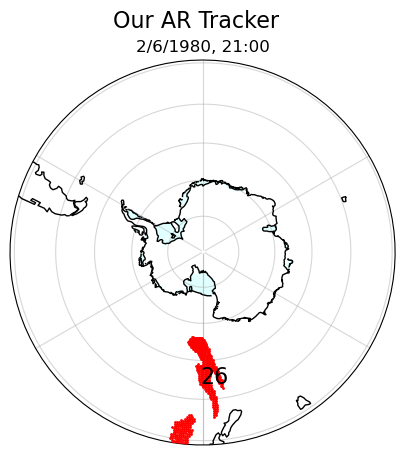

In [16]:
ani = make_movie(stormtime_df, 'Our AR Tracker')
ani.save('/home/jovyan/extreme_antarctic_ARs/notebooks/misc/movie.gif', progress_callback=save_progress)

In [17]:
jonathans = xr.open_dataset('/home/jovyan/extreme_antarctic_ARs/data/wille_ar_catalogs/MERRA2.ar_tag.Wille_v2.4_vIVT.3hourly.19800101-19801231.nc')

In [55]:
start = movie_times[0]
stop = movie_times[-1]
sub_da = jonathans.sel(time=slice(start, stop)).ar_binary_tag

In [56]:
levels = np.array([0.5,1.5]) # levels for the colormap 
def plt_time(j):
    time_slice = sub_da.isel(time=j)
    ax.contourf(time_slice.lon, time_slice.lat, time_slice, levels=levels, colors='gray', transform=ccrs.PlateCarree(), zorder=31)
    ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    #land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
    #ax.add_feature(land_50m,linewidth=3)
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax.coastlines(resolution='110m',linewidth=1,zorder=32)    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.gridlines(alpha=0.5, zorder=33)
    time_ts = pd.Timestamp(time_slice.time.values)
    ax.set_title(f'{time_ts.month}/{time_ts.day}/{time_ts.year}, {time_ts.hour}:00')


MovieWriter ffmpeg unavailable; using Pillow instead.


Saving frame 0/37
Saving frame 20/37


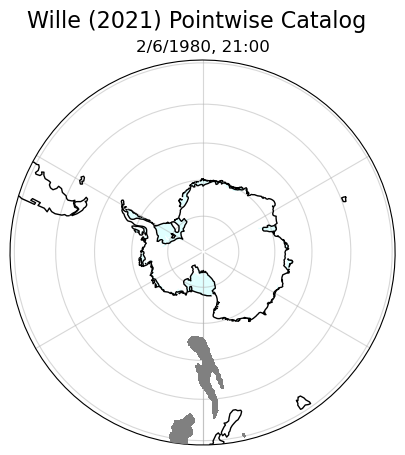

In [58]:
# instantiate the animation
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
plt_time(0)
fig.suptitle('Wille (2021) Pointwise Catalog', fontsize=16);

def update_img(i):
    ax.clear()
    plt_time(i)

ani = animation.FuncAnimation(fig, update_img, frames=len(movie_times))
ani.save('/home/jovyan/extreme_antarctic_ARs/notebooks/misc/jonathans_catalog.gif', progress_callback=save_progress)

In [61]:
def compute_duration(ar_da):
    days = (ar_da.time.max() - ar_da.time.min()).values.astype('timedelta64[h]').astype(int) + np.timedelta64(3, 'h')
    return days

# grab area file
home_dir = str(Path(os.getcwd()).parents[1])
grid_areas = xr.open_dataset(home_dir + '/data/area/MERRA2_gridarea.nc')
grid_areas = grid_areas.sel(lat=slice(-86, -39)).cell_area

def compute_max_area(ar_da):
    grid_area_storm = grid_areas.sel(lat=ar_da.lat, lon=ar_da.lon)
    max_area = float(ar_da.dot(grid_area_storm).max().values/(1000**2))
    return max_area

In [76]:
example_df['max_area'] = example_df['data_array'].apply(compute_max_area).astype(int)
example_df['duration'] = example_df['data_array'].apply(compute_duration)
example_df.index.names = ['AR Number']

,data_array,is_landfalling,start_date,end_date,max_area,duration
AR Number,,,,,,
26,,False,1980-02-06 21:00:00,1980-02-08 18:00:00,2037151,2 days 00:00:00
27,,True,1980-02-07 18:00:00,1980-02-10 06:00:00,1543501,2 days 15:00:00
28,,False,1980-02-08 00:00:00,1980-02-10 03:00:00,2077245,2 days 06:00:00
29,,True,1980-02-09 12:00:00,1980-02-11 09:00:00,2288201,2 days 00:00:00
30,,False,1980-02-09 12:00:00,1980-02-11 09:00:00,434460,2 days 00:00:00
31,,False,1980-02-09 15:00:00,1980-02-10 03:00:00,303766,0 days 15:00:00

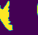
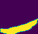
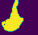
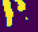

In [77]:
display_catalog(example_df)